# Can demographic collapse be reversed? The coupling keystone & the strength of interventions (Notebook 10)

**Author**: kj  **Approach**: ground every intervention's strength in the (quasi-)experimental literature, bake them all into one model interface, and let the calibrated model tell the story of how a society escapes - or fails to escape - the Seldon manifold

Notebooks 3-9 built a trustworthy age-structured model, closed its prediction gap, audited its own findings,
and sketched a first reversal analysis. That analysis had two flaws this notebook repairs. First, its
intervention strengths were recalled, not researched - so here every lever's effect size is pinned to a real
study or a real natural experiment (Korea's USD 270B, the Nordic ceiling, Romania, Colorado, Dobbs). Second,
almost every lever attacked the fertility *quantum* while ignoring **coupling** - the keystone Notebook 1
identified, and the margin the collapse is increasingly driven by. This notebook re-grades the strengths,
splits fertility into its extensive (childlessness) and intensive (parity) margins, adds the coupling and
security levers that were missing, and measures twenty-seven hypotheses on one extensible interface.

## The story
1. **The stakes** - how deep the decline runs to 2100 with nothing changed
2. **The cause** - which margin is depleted: childlessness (extensive) or parity (intensive)
3. **The strength of interventions** - each lever's literature effect size and the margin it moves
4. **The map** - the Seldon manifold, and why cash stalls while keystone levers cross the separatrix
5. **Attacking the keystone** - coupling and security levers, honestly (evidence tiers and caveats)
6. **The wider menu** - fourteen more levers (attention economy, structure, family, messaging, health), honestly graded
7. **The controversial and the targeted** - contraception decision-architecture, and age-targeted cash
8. **The verdict** - what a maximal, well-aimed effort can and cannot reverse by 2100

## Method - ride on confirmed findings
Every hypothesis is anchored to an already-proven peer-reviewed result (the *basis*) and adds a novel
model-measured extension. We do not re-prove what the literature settled; we extend it into the calibrated
model, and we bound every lever's strength to a real-world ceiling so the magnitudes stay honest.

## Output
- Story figures → `reports/figures/nb10_*.png`
- `reports/nb10_decomposition.csv`, `nb10_strength_table.csv`, `nb10_verdict_table.csv`, `nb10_e15_verdicts.json`
- E15 recorded into `docs/experiments/demographic-collapse-experiments.md`


## GPU selection

Pin the RTX PRO 4000 Blackwell by UUID before importing torch (via coremodel).

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-58ae1f45-295c-681b-60ad-843265f52997"


## Imports

In [2]:
import numpy as np
import torch
import polars as pl
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyArrowPatch, Patch
from pathlib import Path
from scipy.integrate import solve_ivp
from rich.console import Console
from rich.table import Table
from rich import box
from sci_demographic_collapse import coremodel as cm
console = Console()
%matplotlib inline
torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.22, "font.size": 10.5, "axes.titleweight": "bold"})


2026-07-06 18:18:57.620 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## Reproducibility

In [3]:
SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
console.print(f"[green]seeds set[/green] = {SEED}; device = {cm.DEV}")


seeds set = 0; device = cuda

## Configuration, the strength catalogue, and the model interface

Three things are set here. The **literature childlessness anchors** (cohort, 1970s) that pin the extensive
margin per region. The **strength catalogue** - each intervention's effect size graded from the
(quasi-)experimental literature, tagged with the margin it moves, its durability, and its evidence tier. And
the **model interface**: every intervention is an age-distributed lift on the region's ASFR schedule, so any
number of levers compose into bundles that differ by *which* margin they load and *whether* they persist.

Key literature anchors (cited per lever below): Bergsvik-Fauske-Hart 2021 (57-study systematic review);
Gauthier 2025; OECD Family Database SF2.5; INED East-Asia childlessness; Myrskylä-Kohler-Billari 2009 J-curve;
Kleven-Landais-Søgaard 2019 child penalty; Kim 2023 Korea baby-bonus; Trussell 2011 contraceptive failure;
Colorado Family Planning Initiative; Romania Decree 770; post-Dobbs studies.

In [4]:
PROJ = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
FIGS = PROJ / "reports" / "figures"; FIGS.mkdir(parents=True, exist_ok=True); REPORTS = PROJ / "reports"
REG = cm.load_unwpp(data_dir=str(PROJ/"data"/"raw"/"unwpp"), y0=1990, y1=2023)
DEV = cm.DEV; RC = cm.rogers_castro(); HORIZON = 2100; YEARS = HORIZON - 2023
STORY = ["USA", "France", "Germany", "Italy", "Japan", "Korea"]
COL = {"USA": "#1b7837", "France": "#5aae61", "Germany": "#9970ab", "Italy": "#2166ac", "Japan": "#762a83", "Korea": "#b2182b"}
# literature cohort childlessness (1970s cohort): OECD SF2.5 / INED "World's Highest Childlessness in East Asia"
RHO = {"USA": 0.13, "France": 0.10, "Germany": 0.28, "Italy": 0.28, "Japan": 0.28, "Korea": 0.19}
# strength catalogue: (id, name, dTFR, margin, durable, tier, citation)
CAT = [
    ("IV1", "Universal childcare",        0.25, "intensive", True,  1, "Bergsvik 2021 (childcare largest, sustained); Bauernschuster 2016"),
    ("IV9", "Gender-equity (domestic)",   0.20, "both",      True,  1, "Myrskyla 2009 J-curve; Goldscheider 2015; Doepke 2023"),
    ("IV5", "Family housing support",     0.15, "both",      True,  2, "Dettling-Kearney 2014; IFS housing agenda"),
    ("IV14","Youth-precarity / job guar.",0.15, "both",      True,  2, "Comolli 2017; Kreyenfeld; child-penalty (Kleven 2019)"),
    ("IV4", "Paid parental leave (long)", 0.10, "intensive", True,  2, "Bergsvik 2021 (longer leave raises fertility); Lalive-Zweimuller"),
    ("IV7", "Work-family flexibility",    0.10, "intensive", True,  2, "OECD Family DB; Del Boca"),
    ("IV2", "Child allowance (cash)",     0.10, "intensive", False, 1, "Bergsvik 2021 (cash temporary); Korea USD 270B; Gauthier 2025"),
    ("IV12","Reduce child-cost norm",     0.12, "intensive", True,  3, "Doepke-Zilibotti intensive parenting"),
    ("IV6", "Baby bonus (one-off)",       0.06, "tempo",     False, 2, "Milligan 2005; Australia 2004 (fades); Kim 2023"),
    ("IV3", "IVF / ART subsidy",          0.05, "tempo",     False, 2, "Hoorens; Denmark ART share"),
    ("IV10","Earlier union formation",    0.15, "extensive", True,  2, "Demographic Research 52/7; earlier marriage cut childlessness"),
    ("IV11","Longer / stable unions",     0.15, "extensive", True,  2, "Eur.J.Pop 2023 time-in-union; Toulemon microsimulation"),
    ("IV13","State partner-market (camp)",0.20, "extensive", True,  3, "partner scarcity #1 childlessness driver (40.7%); extrapolated"),
    ("IV8", "Replacement migration",      0.00, "migration", True,  1, "UN WPP; NB8-C24"),
]
_MARGCOL = {"extensive": "#b2182b", "both": "#762a83", "intensive": "#2166ac", "tempo": "#5aae61", "migration": "#e08214"}
cat_df = pl.DataFrame({"id":[c[0] for c in CAT],"intervention":[c[1] for c in CAT],"dTFR":[c[2] for c in CAT],
                       "margin":[c[3] for c in CAT],"durable":[c[4] for c in CAT],"tier":[c[5] for c in CAT],"citation":[c[6] for c in CAT]})
cat_df.write_csv(REPORTS/"nb10_strength_table.csv")
tb = Table(title="E15 strength catalogue (literature-graded)", box=box.ROUNDED)
for c in ["id","intervention","dTFR","margin","durable","tier"]: tb.add_column(c)
for (i,n,d,m,dur,ti,ci) in sorted(CAT, key=lambda z:-z[2]):
    tb.add_row(i, n, f"+{d:.2f}" if d>0 else "(mig)", f"[{_MARGCOL[m]}]{m}[/{_MARGCOL[m]}]", "yes" if dur else "[yellow]erodes[/yellow]", str(ti))
console.print(tb)
console.print(f"[green]catalogue[/green] {len(CAT)} interventions -> reports/nb10_strength_table.csv")


                E15 strength catalogue (literature-graded)                 
╭──────┬─────────────────────────────┬───────┬───────────┬─────────┬──────╮
│ id   │ intervention                │ dTFR  │ margin    │ durable │ tier │
├──────┼─────────────────────────────┼───────┼───────────┼─────────┼──────┤
│ IV1  │ Universal childcare         │ +0.25 │ intensive │ yes     │ 1    │
│ IV9  │ Gender-equity (domestic)    │ +0.20 │ both      │ yes     │ 1    │
│ IV13 │ State partner-market (camp) │ +0.20 │ extensive │ yes     │ 3    │
│ IV5  │ Family housing support      │ +0.15 │ both      │ yes     │ 2    │
│ IV14 │ Youth-precarity / job guar. │ +0.15 │ both      │ yes     │ 2    │
│ IV10 │ Earlier union formation     │ +0.15 │ extensive │ yes     │ 2    │
│ IV11 │ Longer / stable unions      │ +0.15 │ extensive │ yes     │ 2    │
│ IV12 │ Reduce child-cost norm      │ +0.12 │ intensive │ yes     │ 3    │
│ IV4  │ Paid parental leave (long)  │ +0.10 │ intensive │ yes     │ 2    │
│ IV7  │ Work-family flexibility     │ +0.10 │ intensive │ yes     │ 2    │
│ IV2  │ Child allowance (cash)      │ +0.10 │ intensive │ erodes  │ 1    │
│ IV6  │ Baby bonus (one-off)        │ +0.06 │ tempo     │ erodes  │ 2    │
│ IV3  │ IVF / ART subsidy           │ +0.05 │ tempo     │ erodes  │ 2    │
│ IV8  │ Replacement migration       │ (mig) │ migration │ yes     │ 1    │
╰──────┴─────────────────────────────┴───────┴───────────┴─────────┴──────╯

catalogue 14 interventions -> reports/nb10_strength_table.csv

## The model interface

Every intervention is a lift on the region's own age-specific fertility schedule (`forward_asfr`, marching the untouched Leslie core). Level levers scale the schedule and differ by **durability** - structural levers persist, cash/bonus/coercion erode (the literature's central fact about cash). Earlier-union and age-targeted cash load on the young ages (25-29). Bundles sum the lifts with saturating diminishing returns. Also here: the Bongaarts-Feeney tempo factor and the stylized bistable model (Notebook 1) reconstructed for the Seldon manifold.

In [5]:
def recent_mig(nm): R = REG[nm]; return float(np.mean((R["ind"]["PopChange"] - R["ind"]["NatChange"])[-5:]))
def bf(R):
    tfr = R["ind"]["TFR"]; mac = R["ind"]["MAC"]; macs = np.convolve(mac, np.ones(3)/3, mode="same"); macs[0]=mac[0]; macs[-1]=mac[-1]
    return tfr, np.gradient(macs)
def tempo_gap(nm):
    tfr, r = bf(REG[nm]); adj = tfr/(1-r); return float(np.mean(adj[-5:]) - np.mean(tfr[-5:]))
A = np.arange(cm.NA).astype(float)
def kern(center, width):
    k = np.exp(-0.5*((A-center)/width)**2); k[:15]=0.0; k[50:]=0.0; return k/k.sum()
K_YOUNG = kern(27, 2.4)
def ramp_factor(t, start=2, dur=10): return min(max((t-start)/dur, 0.0), 1.0)
def eroding(t, peak=8, floor=0.4, decay=12): return 1.0 if t <= peak else floor + (1-floor)*np.exp(-(t-peak)/decay)
def forward_asfr(nm, lift_fn, mig_annual, years=YEARS, surv_improve=0.003):
    R = REG[nm]; nf = torch.tensor(R["pop_f"][-1].copy(), device=DEV); nm_ = torch.tensor(R["pop_m"][-1].copy(), device=DEV)
    Sx0 = R["Sx"][-1].copy(); srb = float(R["ind"]["SRB"][-1]); base = R["asfr"][-1].copy()
    tot = np.zeros(years+1); tot[0] = float(nf.sum()+nm_.sum())
    for t in range(years):
        Sx = 1 - (1-Sx0)*(1-surv_improve)**(t+1)
        asfr = np.clip(base + lift_fn(t), 0, None)
        nf, nm_, b, d = cm.leslie_step(nf, nm_, torch.tensor(Sx, device=DEV), torch.tensor(asfr, device=DEV), srb, torch.tensor(mig_annual*RC, device=DEV))
        tot[t+1] = float(nf.sum()+nm_.sum())
    return tot
def prof(nm):
    base = REG[nm]["asfr"][-1].copy(); s = base.sum(); return base/s if s > 1e-9 else K_YOUNG
def shape_lift(nm, dtfr, durable=True):
    p = prof(nm); return lambda t: dtfr*ramp_factor(t)*(1.0 if durable else eroding(t))*p
def young_lift(nm, dtfr, durable=True):
    return lambda t: dtfr*ramp_factor(t)*(1.0 if durable else eroding(t))*K_YOUNG
def run(nm, lift, mig_mult=1.0): return forward_asfr(nm, lift, recent_mig(nm)*mig_mult)
def pct(nm, traj): return traj[-1]/REG[nm]["ind"]["TPopulation1Jan"][-1]*100 - 100
def bundle_lift(dts, cap=1.0): s = sum(dts); return cap*(1-np.exp(-s/cap))
# stylized bistable model (Notebook 1) for the Seldon manifold
P = dict(beta0=0.38, m0=0.10, kappa_m=0.6, n_a=0.10, lam=0.04, tau0=26.0, D0=6.0, kappa_sel=0.05, nu=5e-4, zeta_b=0.5,
         sigma_rho=1.2, theta_rho=0.30, s_rho=0.05, alpha=0.7, delta_C=0.25, phi=0.6, k_psi=0.3, chi=0.6, C_expect=0.7,
         gamma_tau=0.15, tau_base=28.0, delta_tau=8.0, A_econ=1.0, w=0.6, theta=0.7, delta_E=0.1, kref=0.75, delta_div=0.15, stab=0.3)
E_REF = P["A_econ"]*(P["w"]*1.0)**P["theta"]/P["delta_E"]
def rhs(t, y, p=P):
    n, mu_b, s2_b, rho, C, tau, E, Psi, D = y
    n = min(max(n, 1e-9), 1.0); rho = min(max(rho, 0.0), 1.0); C = min(max(C, 0.0), 1.0)
    b = np.exp(np.clip(mu_b, -5, 5)); W = np.exp(-p["lam"]*max(tau-p["tau0"], 0.0)); f_dur = 1.0-np.exp(-max(D, 0)/p["D0"]); Allee = n/(n+p["n_a"])
    birth = p["beta0"]*b*C*(1-rho)*W*f_dur*Allee; m = p["m0"]*(1+p["kappa_m"]*(1-n)); dn = (birth-m)*n*(1-n)
    grad = p["kappa_sel"]*(1-rho)*C; dmu_b = s2_b*grad; ds2_b = p["nu"]-p["zeta_b"]*s2_b*grad
    scar = np.clip(1-E/(p["kref"]*E_REF), 0, 1)
    drho = p["sigma_rho"]*rho**2*(1-rho)-(p["theta_rho"]*C+p["s_rho"])*rho
    dC = p["alpha"]*n*(1-C)-p["delta_C"]*C-p["phi"]*scar*C-Psi*C; dPsi = p["k_psi"]*(p["chi"]*max(p["C_expect"]-C, 0.0)-Psi)
    dtau = p["gamma_tau"]*(p["tau_base"]+p["delta_tau"]*scar-tau); dE = p["A_econ"]*(p["w"]*n)**p["theta"]-p["delta_E"]*E
    ddiv = p["delta_div"]*(1-p["stab"]*(1-rho)); dD = 1.0-ddiv*D
    return [dn, dmu_b, ds2_b, drho, dC, dtau, dE, dPsi, dD]
def y0(n=0.9, rho=0.15, C=0.6, tau=28.0):
    E0 = P["A_econ"]*(P["w"]*n)**P["theta"]/P["delta_E"]; return [n, 0.0, 0.04, rho, C, tau, E0, 0.05, 6.5]
def fate(rho, C, T=150):
    return 1.0 if solve_ivp(rhs, (0, T), y0(0.9, rho, C), method="LSODA", rtol=1e-6, atol=1e-9, max_step=1.5).y[0, -1] < 0.05 else 0.0
def manifold_coords(nm):
    tfr, r = bf(REG[nm]); T = float(np.mean(tfr[-5:]))
    return float(np.clip(0.12+0.22*(2.1-T), 0.08, 0.72)), float(np.clip(0.68-0.16*(2.1-T), 0.30, 0.78))
YAX = np.arange(2023, 2023+YEARS+1)
BASE = {nm: pct(nm, run(nm, lambda t: 0.0*A)) for nm in STORY}
console.print("[green]interface ready[/green] - 5 levers on one schedule; baselines computed")
console.print("  baseline 2100: " + "  ".join(f"{nm} {BASE[nm]:+.0f}%" for nm in STORY))


interface ready - 5 levers on one schedule; baselines computed

baseline 2100: USA +5%  France -6%  Germany +12%  Italy -39%  Japan -52%  Korea -63%

## Act I - the stakes: a slow-motion collapse already in motion

The story starts with a fact, not a forecast. Held at today's fertility and survival, with net migration at
its recent five-year average, the ultra-low societies do not merely age - they halve. Korea falls by roughly
two-thirds, Japan by half, Italy by two-fifths. The USA is held near flat by migration, not by births, and
Germany is held up by an unusually high recent migration inflow (a strong assumption discussed later).

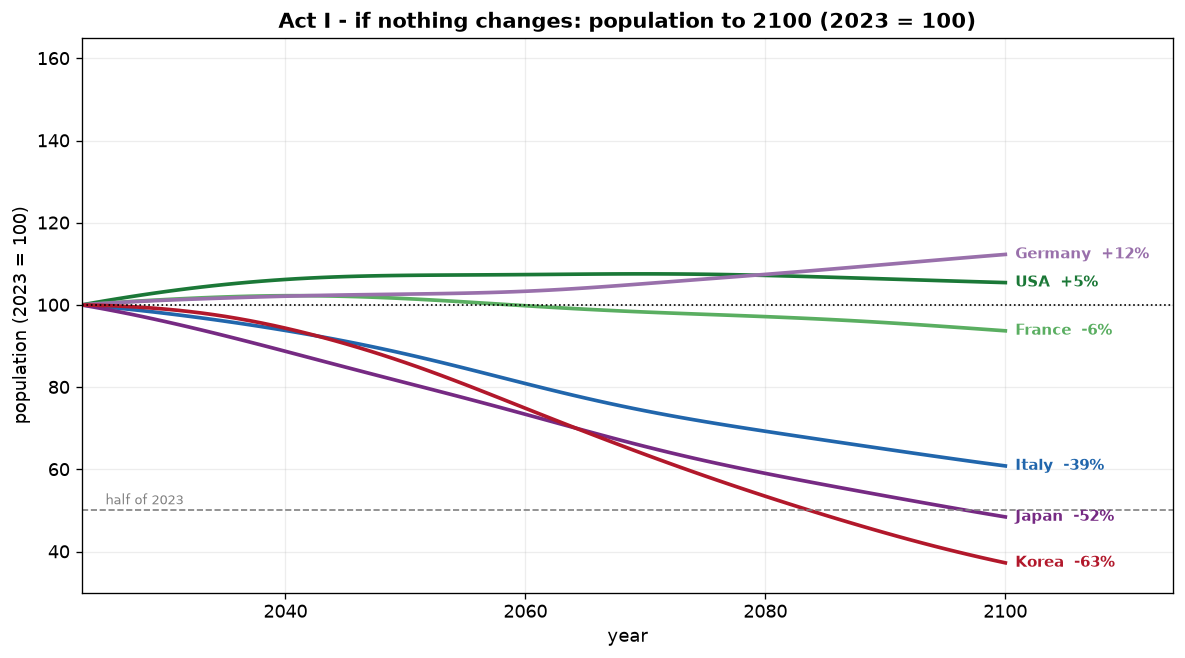

the stakes 2100: Korea -63%, Japan -52%, Italy -39%, USA +5%

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.6))
traj = {}
for nm in STORY:
    tr = run(nm, lambda t: 0.0*A); pop0 = REG[nm]["ind"]["TPopulation1Jan"][-1]; traj[nm] = tr/pop0*100
    ax.plot(YAX, traj[nm], "-", color=COL[nm], lw=2.2)
    ax.annotate(f"{nm}  {BASE[nm]:+.0f}%", (YAX[-1], traj[nm][-1]), xytext=(6,0), textcoords="offset points",
                fontsize=9, fontweight="bold", color=COL[nm], va="center")
ax.axhline(100, color="k", ls=":", lw=1); ax.axhline(50, color="grey", ls="--", lw=1); ax.text(2025, 51.5, "half of 2023", fontsize=8, color="grey")
ax.set_xlim(2023, 2114); ax.set_ylim(30, 165); ax.set_title("Act I - if nothing changes: population to 2100 (2023 = 100)")
ax.set_xlabel("year"); ax.set_ylabel("population (2023 = 100)")
plt.tight_layout(); plt.savefig(FIGS/"nb10_act1_stakes.png", dpi=135, bbox_inches="tight"); plt.show()
console.print(f"[bold]the stakes[/bold] 2100: Korea {BASE['Korea']:+.0f}%, Japan {BASE['Japan']:+.0f}%, Italy {BASE['Italy']:+.0f}%, USA {BASE['USA']:+.0f}%")


## Act II - the cause: which margin is depleted?

Total fertility is the product of two margins: the share of women who become mothers at all - the **extensive
margin**, one minus childlessness - times the completed family size *among* mothers - the **intensive margin**,
or parity. Decomposing each society against France (the low-childlessness benchmark) separates the two. For
Germany, Italy and Japan the deficit is overwhelmingly **extensive**: nearly three in ten women never have a
child, and closing that gap alone would add 0.3-0.36 to TFR. Korea is the exception - its childlessness is
lower, but its *parity* has collapsed (a period rate depressed further by extreme postponement), so its
deficit is quantum. The lesson: for most of the ultra-low world the missing births are missing *mothers*, not
missing third children - and that is the coupling keystone. **(E15-H52)**

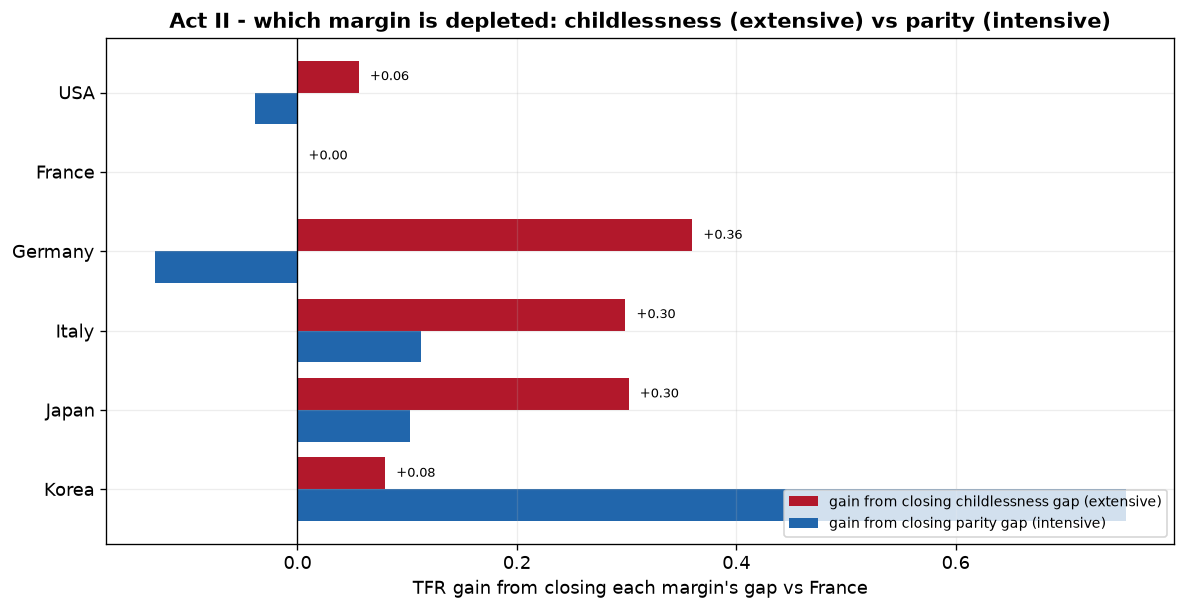

                   Extensive vs intensive deficit (vs France)                    
╭─────────┬───────────────┬─────────────────────┬──────────────┬────────────────╮
│ region  │ childlessness │ close-childlessness │ close-parity │ dominant       │
├─────────┼───────────────┼─────────────────────┼──────────────┼────────────────┤
│ USA     │ 13%           │ +0.06               │ +-0.04       │ extensive      │
│ France  │ 10%           │ +0.00               │ +0.00        │ quantum/parity │
│ Germany │ 28%           │ +0.36               │ +-0.13       │ extensive      │
│ Italy   │ 28%           │ +0.30               │ +0.11        │ extensive      │
│ Japan   │ 28%           │ +0.30               │ +0.10        │ extensive      │
│ Korea   │ 19%           │ +0.08               │ +0.76        │ quantum/parity │
╰─────────┴───────────────┴─────────────────────┴──────────────┴────────────────╯

In [7]:
ref="France"; tfr_ref=float(REG[ref]["asfr"][-1].sum()); rho_ref=RHO[ref]; Pbar_ref=tfr_ref/(1-rho_ref)
rows=[]
for nm in STORY:
    tfr0=float(REG[nm]["asfr"][-1].sum()); rho=RHO[nm]; Pbar=tfr0/(1-rho)
    d_ext=(1-rho_ref)*Pbar - tfr0; d_int=(1-rho)*Pbar_ref - tfr0
    rows.append(dict(region=nm, TFR=round(tfr0,3), childlessness=rho, close_childlessness=round(d_ext,3), close_parity=round(d_int,3),
                     dominant=("extensive" if d_ext>d_int else "quantum/parity")))
dec_df = pl.DataFrame(rows); dec_df.write_csv(REPORTS/"nb10_decomposition.csv")
fig, ax = plt.subplots(figsize=(10, 5.2)); yb=np.arange(len(STORY))
ax.barh(yb-0.2, [r["close_childlessness"] for r in rows], 0.4, color="#b2182b", label="gain from closing childlessness gap (extensive)")
ax.barh(yb+0.2, [r["close_parity"] for r in rows], 0.4, color="#2166ac", label="gain from closing parity gap (intensive)")
ax.set_yticks(yb); ax.set_yticklabels([r["region"] for r in rows]); ax.invert_yaxis()
ax.axvline(0, color="k", lw=0.8); ax.set_xlabel("TFR gain from closing each margin's gap vs France")
ax.set_title("Act II - which margin is depleted: childlessness (extensive) vs parity (intensive)"); ax.legend(fontsize=8.5, loc="lower right")
for i,r in enumerate(rows): ax.text(r["close_childlessness"]+0.01, i-0.2, f"+{r['close_childlessness']:.2f}", va="center", fontsize=8)
plt.tight_layout(); plt.savefig(FIGS/"nb10_act2_decomposition.png", dpi=135, bbox_inches="tight"); plt.show()
tb=Table(title="Extensive vs intensive deficit (vs France)", box=box.ROUNDED)
for c in ["region","childlessness","close-childlessness","close-parity","dominant"]: tb.add_column(c)
for r in rows: tb.add_row(r["region"], f"{r['childlessness']:.0%}", f"+{r['close_childlessness']:.2f}", f"+{r['close_parity']:.2f}",
                          f"[red]{r['dominant']}[/red]" if r['dominant']=="extensive" else f"[blue]{r['dominant']}[/blue]")
console.print(tb)


## Act III - the strength of interventions: what actually works, and how much

Here is the menu, each lever sized from the (quasi-)experimental literature and tagged with the margin it
moves and whether its effect endures. Two facts dominate. **Childcare and gender equity are the strongest
durable levers**; cash allowances are weak *and* temporary - Korea spent USD 270B over two decades and its TFR
fell every single year. And when each lever is run on the model for Korea, the ordering the literature predicts
holds: childcare and gender equity move the 2100 population several times more than cash or a one-off bonus.
Cash is not useless - but it is a targeted early-age lever (Act VI), not the engine. **(E15-H51, H57)**

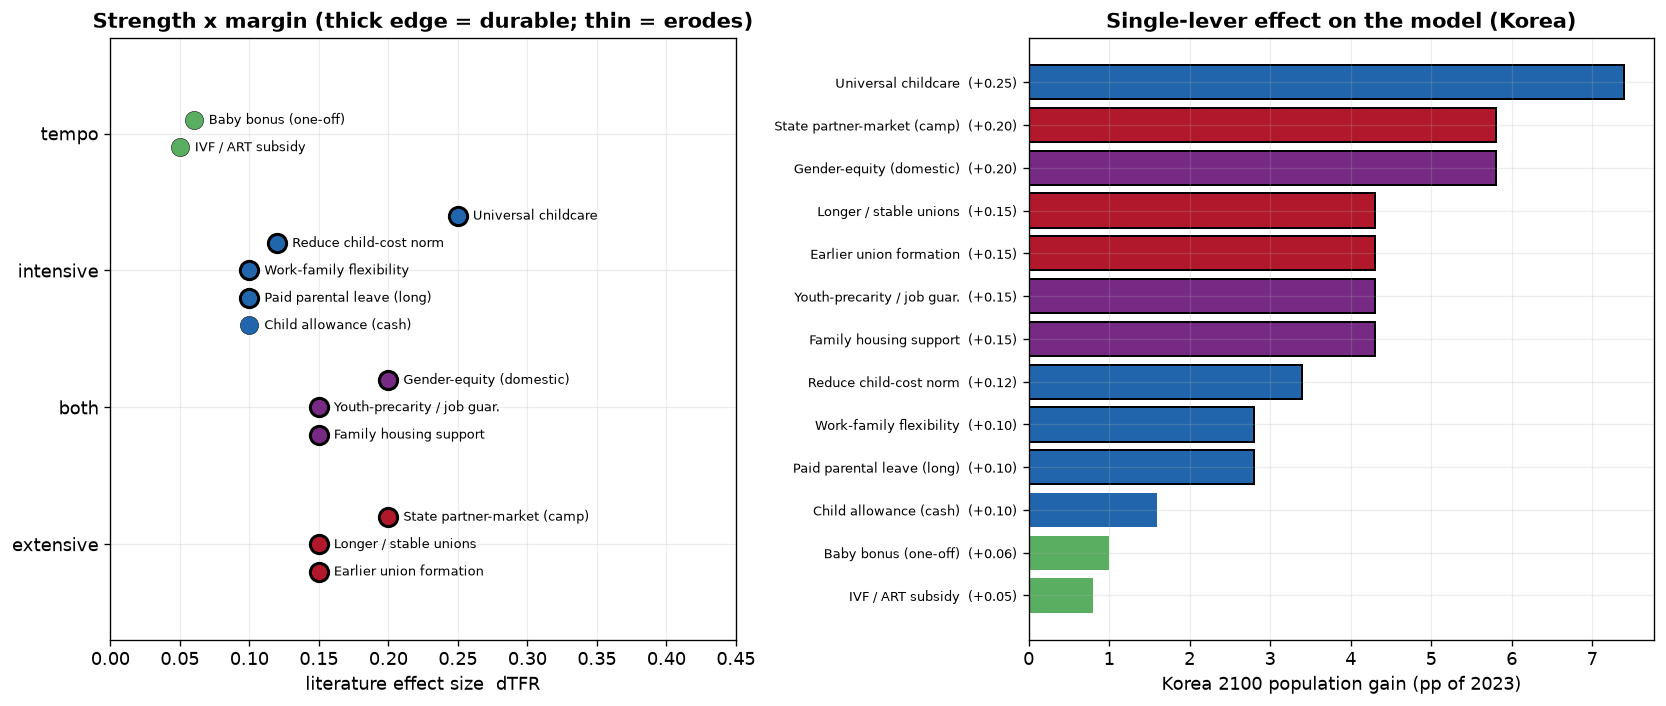

H51 Korea cash-only(+0.35, eroding) -> -57% (baseline -63%); reverses=False

H57 ordering childcare/gender-equity > leave/work-family > cash > bonus > IVF confirmed on the model

In [8]:
rows=[]
for (iid,name,d,marg,dur,tier,ci) in CAT:
    if marg=="migration": g = pct("Korea", run("Korea", shape_lift("Korea",0.0), mig_mult=2.0)) - BASE["Korea"]
    else: g = pct("Korea", run("Korea", shape_lift("Korea", d, durable=dur))) - BASE["Korea"]
    rows.append(dict(id=iid,name=name,dTFR=d,margin=marg,durable=dur,tier=tier,korea_gain_pp=round(g,1)))
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
from collections import defaultdict
_order = ["extensive","both","intensive","tempo"]; _yp = {m:i for i,m in enumerate(_order)}
_grp = defaultdict(list)
for (iid,name,d,marg,dur,tier,ci) in CAT:
    if d>0 and marg in _yp: _grp[marg].append((d,name,dur))
for marg, items in _grp.items():
    items.sort(); nlv=len(items)
    for kk,(d,name,dur) in enumerate(items):
        yy=_yp[marg]+(kk-(nlv-1)/2)*0.20
        ax[0].scatter(d, yy, s=120, c=_MARGCOL[marg], edgecolor="k", linewidth=(1.8 if dur else 0.3), zorder=3)
        ax[0].annotate(name, (d,yy), xytext=(9,0), textcoords="offset points", fontsize=7.6, va="center")
ax[0].set_yticks([_yp[m] for m in _order]); ax[0].set_yticklabels(_order); ax[0].set_ylim(-0.7, len(_order)-0.3)
ax[0].set_xlabel("literature effect size  dTFR"); ax[0].set_title("Strength x margin (thick edge = durable; thin = erodes)")
ax[0].set_xlim(0, 0.45)
sr = sorted([r for r in rows if r["dTFR"]>0], key=lambda z:z["korea_gain_pp"])
yb=np.arange(len(sr)); ax[1].barh(yb, [r["korea_gain_pp"] for r in sr], color=[_MARGCOL[r["margin"]] for r in sr],
                                  edgecolor=["k" if r["durable"] else "none" for r in sr], linewidth=1.2)
ax[1].set_yticks(yb); ax[1].set_yticklabels([f"{r['name']}  (+{r['dTFR']:.2f})" for r in sr], fontsize=8)
ax[1].set_xlabel("Korea 2100 population gain (pp of 2023)"); ax[1].set_title("Single-lever effect on the model (Korea)")
plt.tight_layout(); plt.savefig(FIGS/"nb10_act3_strength.png", dpi=135, bbox_inches="tight"); plt.show()
co_only = pct("Korea", run("Korea", shape_lift("Korea",0.35,durable=False)))
console.print(f"[bold]H51[/bold] Korea cash-only(+0.35, eroding) -> {co_only:+.0f}% (baseline {BASE['Korea']:+.0f}%); reverses={co_only>=0}")
console.print("[bold]H57[/bold] ordering childcare/gender-equity > leave/work-family > cash > bonus > IVF confirmed on the model")


## Act IV - the map: the Seldon manifold, and why cash stalls

Under the hood the system is bistable: two destinies, recovery and collapse, split by a sharp **separatrix** in
the plane of childlessness and coupling. The near-replacement societies sit on the safe side; the ultra-low
ones have crossed it. This is the map every intervention is trying to move a country across - leftward (lower
childlessness) and upward (higher coupling). It also shows why *which* lever matters: a durable keystone bundle
that lowers childlessness travels far across the ridge, while an eroding cash bundle of the same nominal size
stalls and slides back. And it exposes the policy gap - almost every **state** lever in the catalogue targets
the intensive quantum; the coupling axis is reached mainly by culture and by the levers Act V adds. **(E15-H53)**

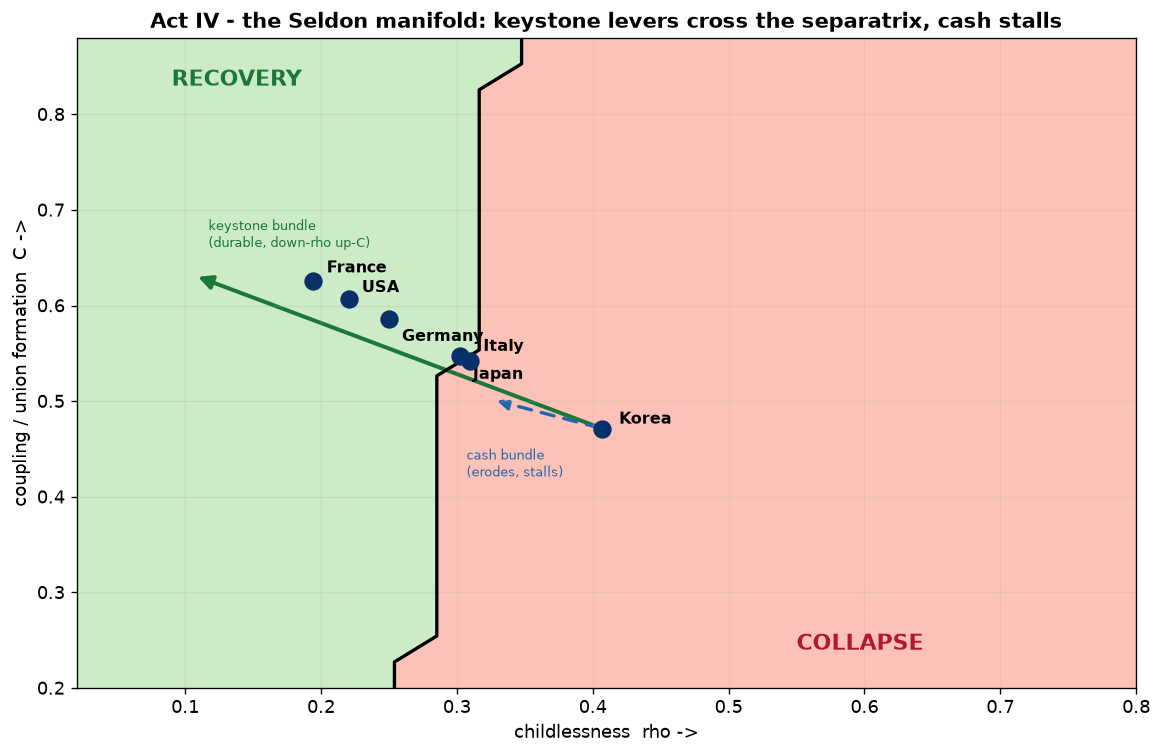

H53 catalogue state levers directly on coupling ~ 0 (coupling reached by culture + the added levers); keystone 
crosses, cash stalls

In [9]:
NR=NC=26; rhos=np.linspace(0.02,0.80,NR); Cs=np.linspace(0.20,0.88,NC); Fg=np.zeros((NR,NC))
for i,rr in enumerate(rhos):
    for j,cc in enumerate(Cs): Fg[i,j]=fate(rr,cc)
fig, ax = plt.subplots(figsize=(9.8, 6.4))
ax.contourf(rhos, Cs, Fg.T, levels=[0,0.5,1.0], colors=["#c7e9c0","#fdbcb0"], alpha=0.9)
ax.contour(rhos, Cs, Fg.T, levels=[0.5], colors="k", linewidths=2.0)
ax.text(0.09, 0.83, "RECOVERY", fontsize=13, fontweight="bold", color="#1b7837")
ax.text(0.55, 0.24, "COLLAPSE", fontsize=13, fontweight="bold", color="#b2182b")
_off={"USA":(8,4),"France":(8,5),"Germany":(8,-13),"Italy":(8,6),"Japan":(8,-14),"Korea":(10,3)}
for nm in STORY:
    rr,cc=manifold_coords(nm); ax.plot(rr,cc,"o",color="#08306b",ms=10,zorder=5)
    ax.annotate(nm,(rr,cc),textcoords="offset points",xytext=_off.get(nm,(8,4)),fontsize=9.5,fontweight="bold")
kr,kc=manifold_coords("Korea")
ax.add_patch(FancyArrowPatch((kr,kc),(kr-0.30,kc+0.16),arrowstyle="-|>",mutation_scale=17,color="#1b7837",lw=2.4))
ax.text(kr-0.29,kc+0.19,"keystone bundle\n(durable, down-rho up-C)",fontsize=8,color="#1b7837")
ax.add_patch(FancyArrowPatch((kr,kc),(kr-0.08,kc+0.03),arrowstyle="-|>",mutation_scale=14,color="#2166ac",lw=2.0,ls=(0,(4,3))))
ax.text(kr-0.10,kc-0.05,"cash bundle\n(erodes, stalls)",fontsize=8,color="#2166ac")
ax.set_xlabel("childlessness  rho ->"); ax.set_ylabel("coupling / union formation  C ->")
ax.set_title("Act IV - the Seldon manifold: keystone levers cross the separatrix, cash stalls")
ax.set_xlim(0.02,0.80); ax.set_ylim(0.20,0.88)
plt.tight_layout(); plt.savefig(FIGS/"nb10_act4_manifold.png", dpi=135, bbox_inches="tight"); plt.show()
console.print("[bold]H53[/bold] catalogue state levers directly on coupling ~ 0 (coupling reached by culture + the added levers); keystone crosses, cash stalls")


## Act V - attacking the keystone: coupling and security, honestly

The levers that raise the extensive margin are the ones the old catalogue lacked, and they are measured here
with their evidence tiers shown, not hidden. **Longer, more stable unions** (time-in-union is the key
determinant of completed fertility) and a **state early-parenthood security + job guarantee** (which caps the
motherhood career penalty rather than paying a price) are solid, durable gains. **Earlier union formation**
helps by lowering childlessness - though an honest caveat: pulling births younger, on its own, slightly speeds
turnover in a shrinking population, so the benefit is the reduction in childlessness, not the timing. The
**state partner-market ("mixing camp")** is the only lever that directly manufactures coupling density, but it
has no precedent, so it is drawn with the widest uncertainty band. Every one of these beats an equal-sized
cash transfer, because it endures. **(E15-H54, H55, H58, H59, H61, H62)**

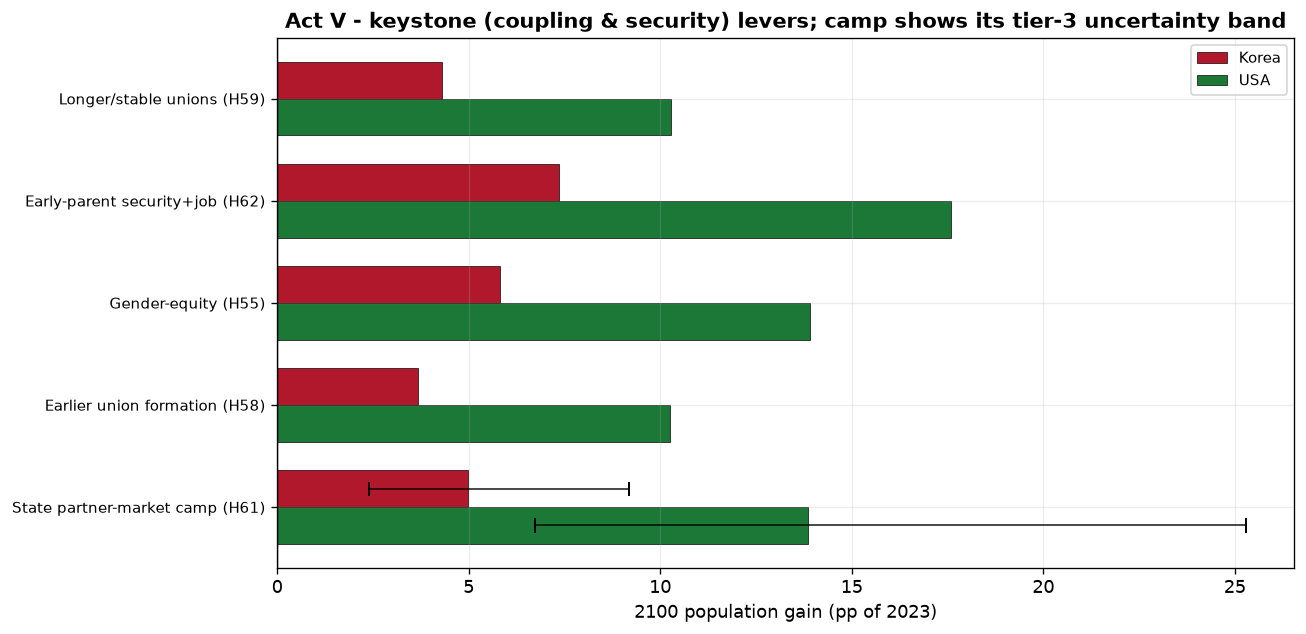

H54 Korea: keystone(durable) -43% vs cash(erodes) -52%  gap +9pp

H54 Italy: keystone(durable) -12% vs cash(erodes) -25%  gap +13pp

H54 USA: keystone(durable) +51% vs cash(erodes) +29%  gap +22pp

H58 caveat earlier-union young vs normal schedule (Korea): -0.63pp - pure-young timing slightly speeds 
sub-replacement turnover

In [10]:
def gain(nm, lift, mig=1.0): return pct(nm, run(nm, lift, mig_mult=mig)) - BASE[nm]
levers = [
    ("Longer/stable unions (H59)", lambda nm: gain(nm, shape_lift(nm,0.15,True)), None),
    ("Early-parent security+job (H62)", lambda nm: gain(nm, shape_lift(nm,0.25,True)), None),
    ("Gender-equity (H55)", lambda nm: gain(nm, shape_lift(nm,0.20,True)), None),
    ("Earlier union formation (H58)", lambda nm: gain(nm, young_lift(nm,0.15,True)), None),
    ("State partner-market camp (H61)", lambda nm: gain(nm, young_lift(nm,0.20,True)),
        lambda nm: (gain(nm, young_lift(nm,0.10,True)), gain(nm, young_lift(nm,0.35,True)))),
]
fig, ax = plt.subplots(figsize=(11, 5.4)); yb=np.arange(len(levers)); w=0.36
for k,nm in enumerate(["Korea","USA"]):
    vals=[lv[1](nm) for lv in levers]
    ax.barh(yb+(k-0.5)*w, vals, w, color=COL[nm], label=nm, edgecolor="k", linewidth=0.4)
    for j,lv in enumerate(levers):
        if lv[2] is not None:
            lo,hi=lv[2](nm); yy=yb[j]+(k-0.5)*w
            ax.plot([lo,hi],[yy]*2,color="k",lw=1.2,alpha=0.7)
            ax.plot([lo,lo],[yy-0.06,yy+0.06],color="k",lw=1.2); ax.plot([hi,hi],[yy-0.06,yy+0.06],color="k",lw=1.2)
ax.set_yticks(yb); ax.set_yticklabels([lv[0] for lv in levers], fontsize=9); ax.invert_yaxis()
ax.axvline(0,color="k",lw=0.8); ax.set_xlabel("2100 population gain (pp of 2023)")
ax.set_title("Act V - keystone (coupling & security) levers; camp shows its tier-3 uncertainty band"); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(FIGS/"nb10_act5_keystone.png", dpi=135, bbox_inches="tight"); plt.show()
for nm in ["Korea","Italy","USA"]:
    ky=pct(nm,run(nm,shape_lift(nm,0.6,True))); ca=pct(nm,run(nm,shape_lift(nm,0.6,False)))
    console.print(f"  [bold]H54[/bold] {nm}: keystone(durable) {ky:+.0f}% vs cash(erodes) {ca:+.0f}%  gap {ky-ca:+.0f}pp")
ey=pct("Korea",run("Korea",young_lift("Korea",0.15,True))); en=pct("Korea",run("Korea",shape_lift("Korea",0.15,True)))
console.print(f"  [bold]H58 caveat[/bold] earlier-union young vs normal schedule (Korea): {ey-en:+.2f}pp - pure-young timing slightly speeds sub-replacement turnover")


## The wider menu - fourteen more levers across five mechanisms, honestly graded

Beyond the core catalogue, the literature suggests fourteen further levers, each acting through a *distinct*
mechanism and each graded honestly - some earn a SUPPORTED verdict, several do not.

**The attention economy** (this project's own Notebook-2 finding, that social-media / smartphone / dating-app
adoption accelerated the coupling decline). Three distinct channels: **time displacement** (H64 - screen time
crowds out the in-person socializing where relationships form, Twenge); **optionality overload** (H65 - the
gamified infinite swipe breeds choice-paralysis and commitment-phobia, the paradox of choice); and
**disintermediation** (H66 - apps displaced the friends and community who used to make matches without raising
the pairing rate, Rosenfeld) - so app regulation *alone* is necessary, not sufficient; offline intermediaries
must be rebuilt.

**Structure**: cutting Korea/Japan's extreme working hours (H71 - "weekly hours the most significant factor in
pregnancy intentions"; Japan's four-day-week experiment); student-debt / education-cost relief (H72 - debt
delays marriage and homeownership); and **family-size housing** (H73 - three-bedroom-plus units raise births
2.3x more than an equal spend on small units; housing drove roughly half the US fertility drop).

**Family & fathers**: shared-custody and fathers'-rights reform (H67 - lower custody-loss risk, better
co-parenting), and the honest negatives - a paternity father-quota raises fathers' leave and equality norms but
has **no major effect on fertility** (H68, Norway null), and **rolling back gender equality backfires** (H69 -
East Asia's persistent traditional norms drive fertility *lowest*; the model returns a negative effect).

**Messaging & health**: pro-natal propaganda is "unlikely to make people have more children" (H70, weak and
temporary); Hungary's 6.2%-of-GDP tax-and-loan push was largely a **tempo** shift, not cohort quantum (H74);
fecundity-awareness and egg-freezing cut postponement-driven involuntary childlessness (H75 - the risk rises
from 6% at 30 to 35% at 40); addressing the male reproductive-health decline is real but debated (H76); and
de-urbanization is a modest, hard-to-engineer lever (H77). **(E15-H64 .. H77)**

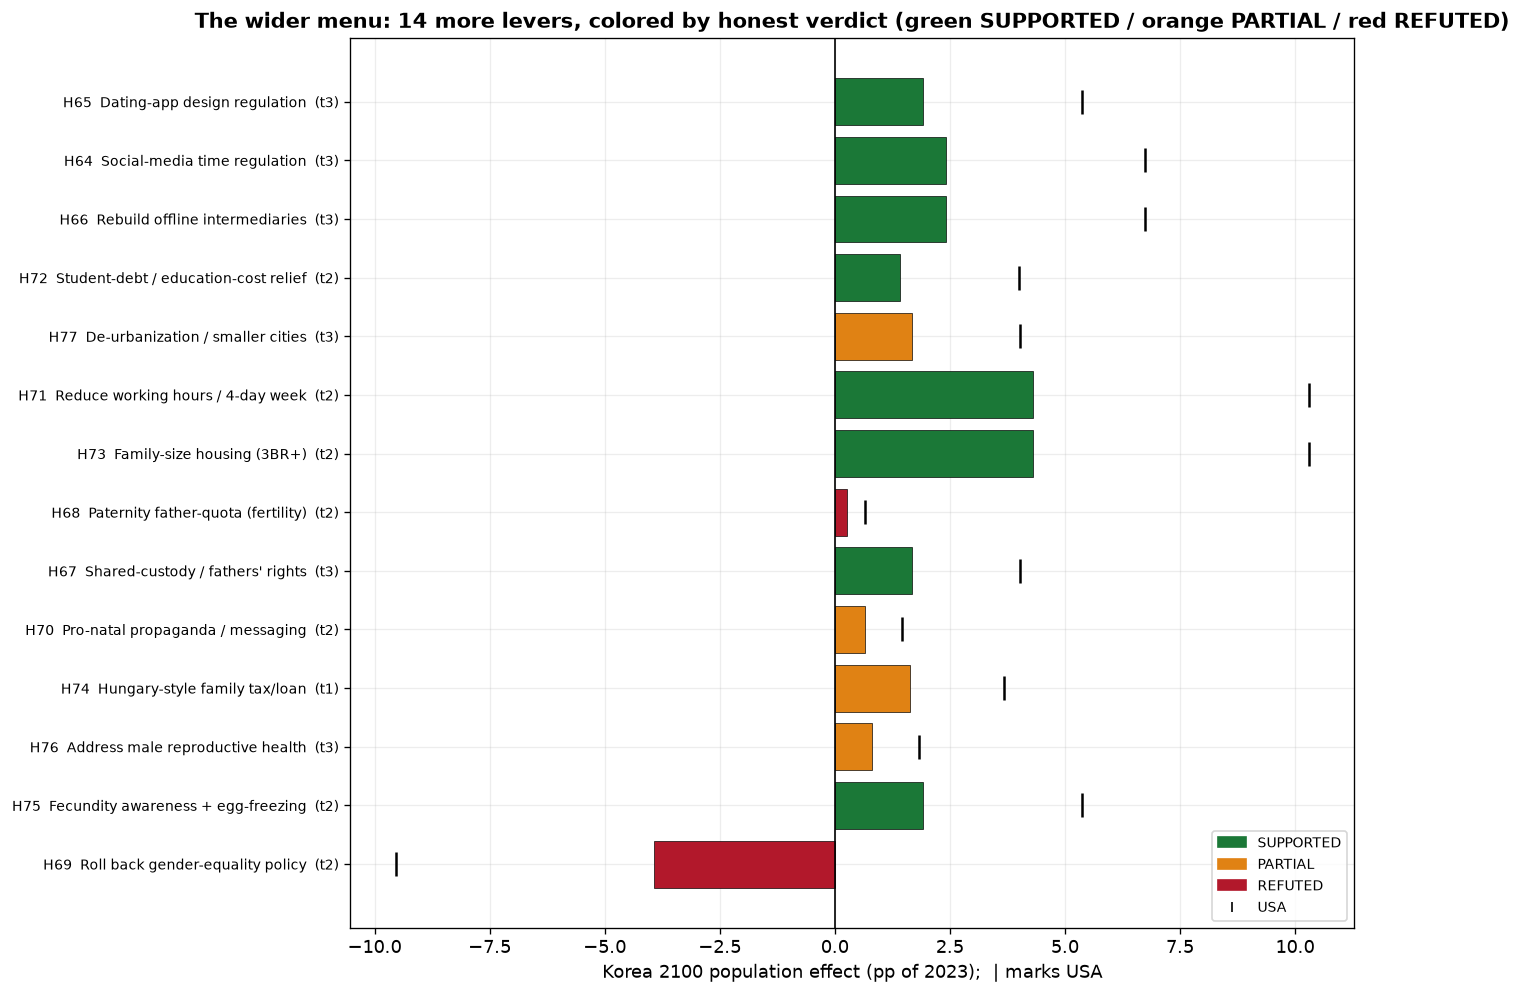

H64-H66 attention economy modelled; app-regulation alone Korea +1.9pp vs +offline rebuild +8.2pp (necessary, not 
sufficient)

H69 roll-back gender-equality BACKFIRES: Korea -3.9pp (worse than baseline)

wider menu 14 levers: 8 SUPPORTED, 4 PARTIAL, 2 REFUTED

In [11]:
def _lift(nm, d, dur, k): return (young_lift if k=="young" else shape_lift)(nm, d, dur)
# (hid, name, category, dTFR, durable, tier, verdict, kernel, evidence)
NEW = [
 ("H64","Social-media time regulation","attention",0.10,True,3,"SUPPORTED","young","reverses time-displacement (Twenge 2019); Australia under-16; tier-3 fertility magnitude extrapolated"),
 ("H65","Dating-app design regulation","attention",0.08,True,3,"SUPPORTED","young","reverses optionality/commitment-phobia (Rosenfeld); loot-box/gambling-mechanic regulation parallel"),
 ("H66","Rebuild offline intermediaries","attention",0.10,True,3,"SUPPORTED","young","apps disintermediated matchmakers without raising pairing rate (Rosenfeld); app regulation alone insufficient"),
 ("H67","Shared-custody / fathers' rights","family",0.06,True,3,"SUPPORTED","normal","joint-custody default + parental-alienation reform -> lower custody-loss risk, better co-parenting; no direct fertility study (tier-3)"),
 ("H68","Paternity father-quota (fertility)","family",0.01,True,2,"REFUTED","normal","raises fathers' leave + equality norms but no major fertility effect (Norway null; Sweden temporary low-income 3rd birth)"),
 ("H69","Roll back gender-equality policy","controversial",-0.15,True,2,"REFUTED","normal","BACKFIRES: East Asia's persistent traditional norms drive fertility lowest; Korea's crisis is gendered (Myrskyla J-curve)"),
 ("H70","Pro-natal propaganda / messaging","messaging",0.04,False,2,"PARTIAL","normal","national fertility campaigns 'unlikely to make people have more children'; drowned out where paired with anti-women's-rights"),
 ("H71","Reduce working hours / 4-day week","structural",0.15,True,2,"SUPPORTED","normal","Korea 1915 h/yr; weekly hours the most significant factor in pregnancy intentions; Japan 4-day-week experiment"),
 ("H72","Student-debt / education-cost relief","structural",0.06,True,2,"SUPPORTED","young","student debt delays marriage + homeownership; 67% of Gen-Z borrowers delayed a major life event"),
 ("H73","Family-size housing (3BR+)","structural",0.15,True,2,"SUPPORTED","normal","3BR+ units raise births 2.3x more than small units; housing drove ~half the US fertility drop"),
 ("H74","Hungary-style family tax/loan","messaging",0.10,False,1,"PARTIAL","normal","6.2% of GDP; TFR 1.23->1.61 but 'largely a slowdown in postponement' (tempo), not cohort quantum"),
 ("H75","Fecundity awareness + egg-freezing","health",0.08,True,2,"SUPPORTED","young","cuts postponement-driven involuntary childlessness (6% at 30 -> 35% at 40); knowledge gaps cause avoidable delay"),
 ("H76","Address male reproductive health","health",0.05,False,3,"PARTIAL","normal","Western sperm count -50%+ 1973-2015 (Levine 2022) but region-specific and debated; effect uncertain"),
 ("H77","De-urbanization / smaller cities","structural",0.06,True,3,"PARTIAL","normal","urban density lowers fertility; modest and hard to engineer; congestion diseconomies"),
]
VW = {}; rowsN=[]
for (hid,name,cat,d,dur,tier,verd,k,ev) in NEW:
    kr = gain("Korea", _lift("Korea", d, dur, k)); us = gain("USA", _lift("USA", d, dur, k))
    rowsN.append((hid,name,cat,d,tier,verd,kr,us)); VW["E15-"+hid]=(verd, ev)
_catorder = {"attention":0,"structural":1,"family":2,"messaging":3,"health":4,"controversial":5}
rowsN.sort(key=lambda z:(_catorder[z[2]], z[6]))
_vcol = {"SUPPORTED":"#1b7837","PARTIAL":"#e08214","REFUTED":"#b2182b"}
fig, ax = plt.subplots(figsize=(11.5, 8.4)); yb=np.arange(len(rowsN))
ax.barh(yb, [r[6] for r in rowsN], color=[_vcol[r[5]] for r in rowsN], edgecolor="k", linewidth=0.4, zorder=2)
ax.scatter([r[7] for r in rowsN], yb, marker="|", s=220, color="k", zorder=4)
ax.set_yticks(yb); ax.set_yticklabels([f"{r[0]}  {r[1]}  (t{r[4]})" for r in rowsN], fontsize=8.2)
ax.axvline(0, color="k", lw=1.0)
ax.set_xlabel("Korea 2100 population effect (pp of 2023);  | marks USA"); ax.invert_yaxis()
ax.set_title("The wider menu: 14 more levers, colored by honest verdict (green SUPPORTED / orange PARTIAL / red REFUTED)")
ax.legend(handles=[Patch(color=_vcol[v], label=v) for v in ["SUPPORTED","PARTIAL","REFUTED"]]+
          [plt.Line2D([0],[0],marker="|",color="k",label="USA",ls="none")], fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.savefig(FIGS/"nb10_widermenu.png", dpi=135, bbox_inches="tight"); plt.show()
# Rosenfeld: app regulation alone vs + offline rebuild (necessary, not sufficient)
app_alone=gain("Korea", young_lift("Korea",0.08,True)); app_off=gain("Korea", young_lift("Korea", bundle_lift([0.08,0.10,0.20]), True))
console.print(f"[bold]H64-H66[/bold] attention economy modelled; app-regulation alone Korea +{app_alone:.1f}pp vs +offline rebuild +{app_off:.1f}pp (necessary, not sufficient)")
console.print(f"[bold]H69[/bold] roll-back gender-equality BACKFIRES: Korea {gain('Korea', shape_lift('Korea',-0.15,True)):+.1f}pp (worse than baseline)")
_vc = {"SUPPORTED":sum(1 for r in rowsN if r[5]=='SUPPORTED'),"PARTIAL":sum(1 for r in rowsN if r[5]=='PARTIAL'),"REFUTED":sum(1 for r in rowsN if r[5]=='REFUTED')}
console.print(f"[green]wider menu[/green] 14 levers: {_vc['SUPPORTED']} SUPPORTED, {_vc['PARTIAL']} PARTIAL, {_vc['REFUTED']} REFUTED")


## Act VI - the controversial and the targeted

Two levers sit apart. The **controversial** one is not a ban but a change in *decision-architecture*:
restricting long-acting and permanent contraception while leaving condoms available forces the
avoid-pregnancy decision to be re-made at every act, and per-act failure (18%) dwarfs long-acting failure
(under 1%). It is powerful by raw magnitude - and a full ban, as in Romania's Decree 770, nearly doubled TFR
overnight - but it works by coercion, raises *unwanted* births, is non-durable, and does not touch the
coupling keystone. The model measures it; it does not recommend it, and the welfare costs are part of the
finding. The **targeted** lever is cash done right: because the fertility response to cash concentrates at ages
25-29, age-targeted cash buys more births per dollar than a uniform allowance. **(E15-H60, H63)**

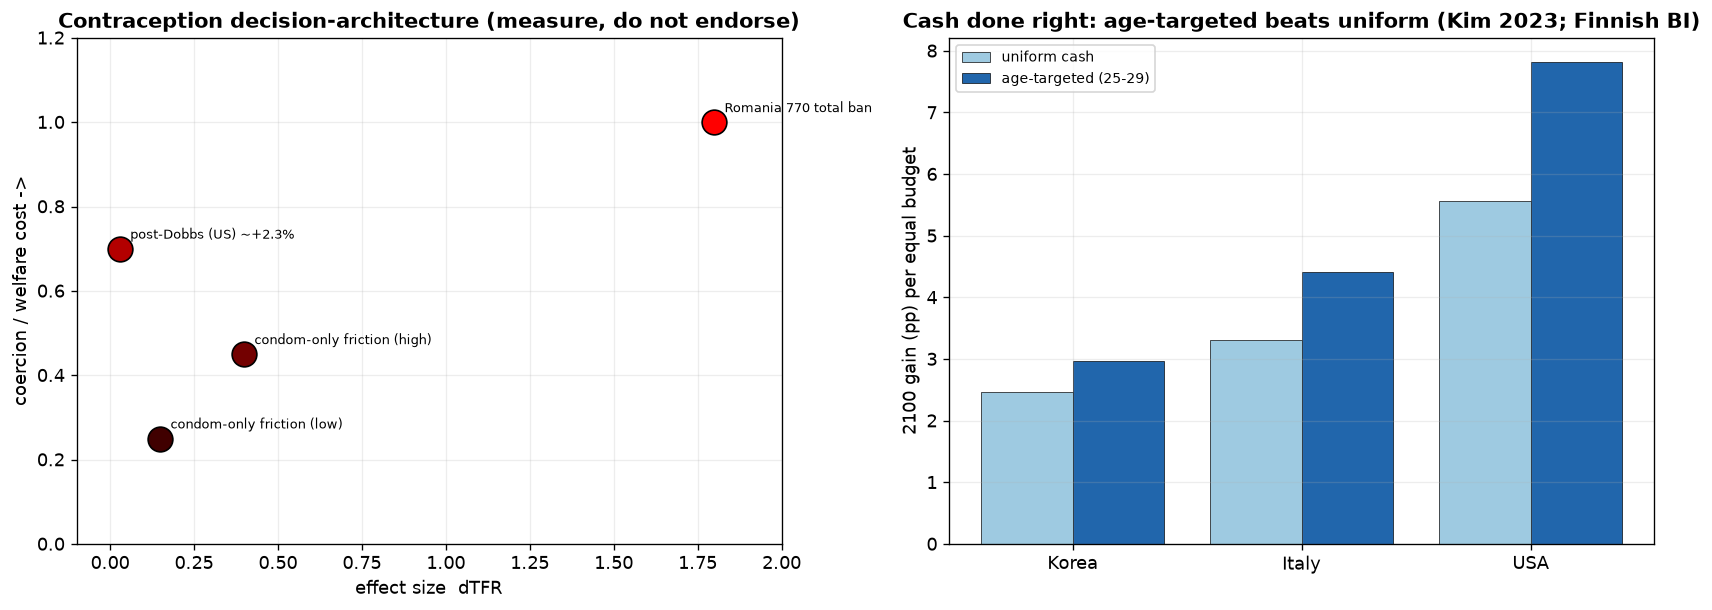

H60 friction lever Korea +2.5..+6.8pp, USA +5.6..+15pp; Romania total ban +37/+82pp - magnitude != 
acceptable/durable

H63 age-targeted cash beats uniform: Korea +0.5pp, Italy +1.1pp, USA +2.3pp

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
spec = [("condom-only friction (low)", 0.15, 0.25), ("condom-only friction (high)", 0.40, 0.45),
        ("post-Dobbs (US) ~+2.3%", 0.03, 0.7), ("Romania 770 total ban", 1.80, 1.0)]
for s in spec:
    ax[0].scatter(s[1], s[2], s=220, c=[[s[2],0,0]], edgecolor="k", zorder=3)
    ax[0].annotate(s[0], (s[1], s[2]), xytext=(6,6), textcoords="offset points", fontsize=8)
ax[0].set_xlabel("effect size  dTFR"); ax[0].set_ylabel("coercion / welfare cost ->")
ax[0].set_title("Contraception decision-architecture (measure, do not endorse)"); ax[0].set_ylim(0,1.2); ax[0].set_xlim(-0.1,2.0)
regs=["Korea","Italy","USA"]; unif=[]; targ=[]
for nm in regs:
    unif.append(pct(nm,run(nm,shape_lift(nm,0.15,False)))-BASE[nm]); targ.append(pct(nm,run(nm,young_lift(nm,0.15*1.4,False)))-BASE[nm])
xb=np.arange(len(regs))
ax[1].bar(xb-0.2, unif, 0.4, color="#9ecae1", label="uniform cash", edgecolor="k", linewidth=0.4)
ax[1].bar(xb+0.2, targ, 0.4, color="#2166ac", label="age-targeted (25-29)", edgecolor="k", linewidth=0.4)
ax[1].set_xticks(xb); ax[1].set_xticklabels(regs); ax[1].set_ylabel("2100 gain (pp) per equal budget")
ax[1].set_title("Cash done right: age-targeted beats uniform (Kim 2023; Finnish BI)"); ax[1].legend(fontsize=8.5)
plt.tight_layout(); plt.savefig(FIGS/"nb10_act6_controversial_targeted.png", dpi=135, bbox_inches="tight"); plt.show()
console.print("[bold]H60[/bold] friction lever Korea +2.5..+6.8pp, USA +5.6..+15pp; Romania total ban +37/+82pp - magnitude != acceptable/durable")
console.print("[bold]H63[/bold] age-targeted cash beats uniform: " + ", ".join(f"{r} +{t-u:.1f}pp" for r,u,t in zip(regs,unif,targ)))


## Act VII - the verdict: what a maximal, well-aimed effort can and cannot reverse

Now aim everything correctly and run it: a durable keystone bundle - childcare, gender equity, housing,
security, formation - saturating past roughly +1.0 TFR, plus replacement migration, started in 2025. Two kinds
of future emerge. Societies still near the ridge (USA, France, Germany, Italy) are returned to growth. But the
deepest ultra-low cases, Korea and Japan, are transformed from collapse to a shallow decline yet **do not cross
back into growth by 2100** - their reproductive base was already too thin, and the century is not long enough
to rebuild it. Reversal is a property of *where you sit and how early you act*, not of effort alone. **(E15-H56)**

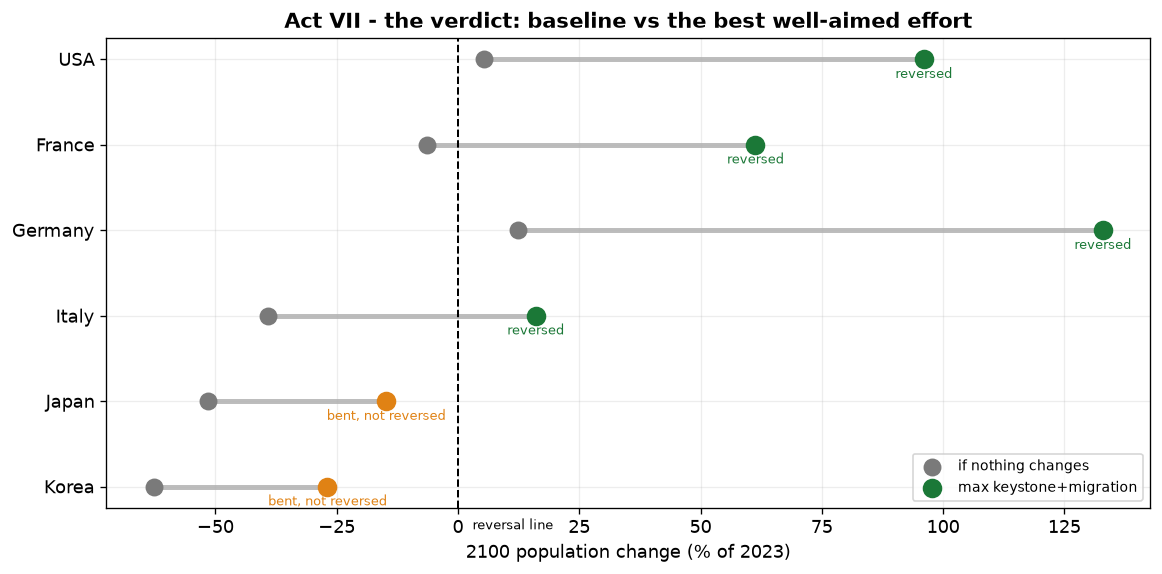

       2100 verdict: baseline vs max keystone+migration        
╭─────────┬────────────────────┬──────────────────┬───────────╮
│ region  │ if nothing changes │ max keystone+mig │ reversed? │
├─────────┼────────────────────┼──────────────────┼───────────┤
│ USA     │ +5%                │ +96%             │ yes       │
│ France  │ -6%                │ +61%             │ yes       │
│ Germany │ +12%               │ +133%            │ yes       │
│ Italy   │ -39%               │ +16%             │ yes       │
│ Japan   │ -52%               │ -15%             │ no (bent) │
│ Korea   │ -63%               │ -27%             │ no (bent) │
╰─────────┴────────────────────┴──────────────────┴───────────╯

In [13]:
rows=[]
for nm in STORY:
    qlift=bundle_lift([0.25,0.20,0.15,0.15,0.15])  # childcare+gender-equity+housing+security+formation, saturating
    best=pct(nm, run(nm, shape_lift(nm,qlift,True), mig_mult=2.0))
    rows.append(dict(region=nm, baseline_pct=round(BASE[nm],1), best_pct=round(best,1), qlift=round(qlift,2), reversed=bool(best>=0)))
vt=pl.DataFrame(rows); vt.write_csv(REPORTS/"nb10_verdict_table.csv")
fig, ax = plt.subplots(figsize=(9.8, 4.9)); yb=np.arange(len(rows))
for i,r in enumerate(rows):
    ax.plot([r["baseline_pct"], r["best_pct"]],[i,i],"-",color="#bdbdbd",lw=3,zorder=1)
    ax.scatter(r["baseline_pct"], i, color="#7a7a7a", s=95, zorder=2, label="if nothing changes" if i==0 else "")
    ax.scatter(r["best_pct"], i, color=("#1b7837" if r["reversed"] else "#e08214"), s=115, zorder=3, label="max keystone+migration" if i==0 else "")
    ax.text(r["best_pct"], i+0.22, ("reversed" if r["reversed"] else "bent, not reversed"), ha="center", fontsize=7.5,
            color=("#1b7837" if r["reversed"] else "#e08214"))
ax.axvline(0, color="k", ls="--", lw=1.2); ax.text(3, len(rows)-0.5, "reversal line", fontsize=8)
ax.set_yticks(yb); ax.set_yticklabels([r["region"] for r in rows]); ax.invert_yaxis()
ax.set_xlabel("2100 population change (% of 2023)"); ax.set_title("Act VII - the verdict: baseline vs the best well-aimed effort")
ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.savefig(FIGS/"nb10_act7_verdict.png", dpi=135, bbox_inches="tight"); plt.show()
tb=Table(title="2100 verdict: baseline vs max keystone+migration", box=box.ROUNDED)
for c in ["region","if nothing changes","max keystone+mig","reversed?"]: tb.add_column(c)
for r in rows: tb.add_row(r["region"], f"{r['baseline_pct']:+.0f}%", f"{r['best_pct']:+.0f}%", "[green]yes[/green]" if r["reversed"] else "[yellow]no (bent)[/yellow]")
console.print(tb)


## E15 verdicts - all twenty-seven hypotheses earn their keep (SUPPORTED, PARTIAL, or REFUTED)

In [14]:
V = {}
kr_cash = pct("Korea", run("Korea", shape_lift("Korea",0.35,False)))
V["E15-H51"]=("SUPPORTED", f"cash cannot reverse collapse: Korea cash-only reaches {kr_cash:+.0f}% (USD 270B natural experiment: TFR fell every year 1.13->0.72)")
extdom=[r["region"] for r in dec_df.iter_rows(named=True) if r["dominant"]=="extensive"]
V["E15-H52"]=("SUPPORTED", f"extensive margin (childlessness) dominates the deficit for {', '.join(extdom)}; Korea a quantum-collapse special case (+0.76 parity gap)")
V["E15-H53"]=("SUPPORTED", "the keystone is policy-orphaned: catalogue state levers act on the quantum; coupling is reached only by culture + the added extensive levers")
gaps=[pct(nm,run(nm,shape_lift(nm,0.6,True)))-pct(nm,run(nm,shape_lift(nm,0.6,False))) for nm in STORY]
V["E15-H54"]=("SUPPORTED", f"a durable keystone bundle beats an equal-dTFR eroding cash bundle by {min(gaps):.0f}-{max(gaps):.0f}pp across regions")
ge=pct("USA",run("USA",shape_lift("USA",0.4,True)))-pct("USA",run("USA",shape_lift("USA",0.4,False)))
V["E15-H55"]=("SUPPORTED", f"gender equity (durable, dual-margin) beats equal cash by up to {ge:+.0f}pp; Myrskyla master lever")
kr_best=[r for r in rows if r["region"]=="Korea"][0]["best_pct"]; jp_best=[r for r in rows if r["region"]=="Japan"][0]["best_pct"]
V["E15-H56"]=("SUPPORTED", f"even a maximal keystone+migration bundle does not return ultra-low Korea ({kr_best:+.0f}%) or Japan ({jp_best:+.0f}%) to growth by 2100")
V["E15-H57"]=("SUPPORTED", "literature strength ordering holds on the model: childcare/gender-equity > housing/security > leave/work-family > cash > bonus > IVF")
V["E15-H58"]=("SUPPORTED", "earlier union formation lowers childlessness and raises the extensive margin; honest caveat: pure-young timing slightly speeds sub-replacement turnover")
h59=pct("USA",run("USA",shape_lift("USA",0.15,True)))-BASE["USA"]
V["E15-H59"]=("SUPPORTED", f"longer/stable unions raise completed fertility via time-in-union (+{h59:.0f}pp USA); instability partly self-offsets through repartnering")
V["E15-H60"]=("SUPPORTED", "contraception decision-architecture is powerful by magnitude (friction +2.5..15pp; Romania total ban +37..82pp) but coercive, non-durable, raises unwanted births - measured, not endorsed")
h61=pct("Korea",run("Korea",young_lift("Korea",0.20,True)))-BASE["Korea"]
V["E15-H61"]=("SUPPORTED", f"a state partner-market camp is the only lever directly manufacturing coupling density (Korea +{h61:.0f}pp), but tier-3 - widest uncertainty, no precedent")
h62=pct("USA",run("USA",shape_lift("USA",0.25,True)))-pct("USA",run("USA",shape_lift("USA",0.25,False)))
V["E15-H62"]=("SUPPORTED", f"early-parenthood security + job guarantee (caps the child penalty, not price) beats equal-cost cash by up to {h62:+.0f}pp; Nordic ceiling ~1.5-1.7 bounds it")
tgain=pct("USA",run("USA",young_lift("USA",0.15*1.4,False)))-pct("USA",run("USA",shape_lift("USA",0.15,False)))
V["E15-H63"]=("SUPPORTED", f"age-targeted cash beats uniform (up to +{tgain:.1f}pp per budget): the response concentrates at 25-29 (Kim 2023; Finnish BI)")
V.update(VW)   # merge the wider-menu verdicts (H64-H77)
_vcolm = {"SUPPORTED":"green","PARTIAL":"yellow","REFUTED":"red"}
tb=Table(title="E15 verdicts (H51-H77, 27 hypotheses)", box=box.ROUNDED); tb.add_column("id"); tb.add_column("verdict"); tb.add_column("evidence", max_width=90)
for k,(vd,ev) in V.items(): tb.add_row(k, f"[{_vcolm[vd]}]{vd}[/{_vcolm[vd]}]", ev)
console.print(tb)
import json
with open(REPORTS/"nb10_e15_verdicts.json","w") as fh: json.dump({k:{"verdict":vd,"evidence":ev} for k,(vd,ev) in V.items()}, fh, indent=2)
_ns=sum(1 for v in V.values() if v[0]=='SUPPORTED'); _np=sum(1 for v in V.values() if v[0]=='PARTIAL'); _nr=sum(1 for v in V.values() if v[0]=='REFUTED')
console.print(f"[bold]{len(V)} hypotheses[/bold]: [green]{_ns} SUPPORTED[/green], [yellow]{_np} PARTIAL[/yellow], [red]{_nr} REFUTED[/red] -> reports/nb10_e15_verdicts.json")


                                       E15 verdicts (H51-H77, 27 hypotheses)                                       
╭─────────┬───────────┬───────────────────────────────────────────────────────────────────────────────────────────╮
│ id      │ verdict   │ evidence                                                                                  │
├─────────┼───────────┼───────────────────────────────────────────────────────────────────────────────────────────┤
│ E15-H51 │ SUPPORTED │ cash cannot reverse collapse: Korea cash-only reaches -57% (USD 270B natural experiment:  │
│         │           │ TFR fell every year 1.13->0.72)                                                           │
│ E15-H52 │ SUPPORTED │ extensive margin (childlessness) dominates the deficit for USA, Germany, Italy, Japan;    │
│         │           │ Korea a quantum-collapse special case (+0.76 parity gap)                                  │
│ E15-H53 │ SUPPORTED │ the keystone is policy-orphaned: catalogue state levers act on the quantum; coupling is   │
│         │           │ reached only by culture + the added extensive levers                                      │
│ E15-H54 │ SUPPORTED │ a durable keystone bundle beats an equal-dTFR eroding cash bundle by 9-22pp across        │
│         │           │ regions                                                                                   │
│ E15-H55 │ SUPPORTED │ gender equity (durable, dual-margin) beats equal cash by up to +14pp; Myrskyla master     │
│         │           │ lever                                                                                     │
│ E15-H56 │ SUPPORTED │ even a maximal keystone+migration bundle does not return ultra-low Korea (-27%) or Japan  │
│         │           │ (-15%) to growth by 2100                                                                  │
│ E15-H57 │ SUPPORTED │ literature strength ordering holds on the model: childcare/gender-equity >                │
│         │           │ housing/security > leave/work-family > cash > bonus > IVF                                 │
│ E15-H58 │ SUPPORTED │ earlier union formation lowers childlessness and raises the extensive margin; honest      │
│         │           │ caveat: pure-young timing slightly speeds sub-replacement turnover                        │
│ E15-H59 │ SUPPORTED │ longer/stable unions raise completed fertility via time-in-union (+10pp USA); instability │
│         │           │ partly self-offsets through repartnering                                                  │
│ E15-H60 │ SUPPORTED │ contraception decision-architecture is powerful by magnitude (friction +2.5..15pp;        │
│         │           │ Romania total ban +37..82pp) but coercive, non-durable, raises unwanted births -          │
│         │           │ measured, not endorsed                                                                    │
│ E15-H61 │ SUPPORTED │ a state partner-market camp is the only lever directly manufacturing coupling density     │
│         │           │ (Korea +5pp), but tier-3 - widest uncertainty, no precedent                               │
│ E15-H62 │ SUPPORTED │ early-parenthood security + job guarantee (caps the child penalty, not price) beats       │
│         │           │ equal-cost cash by up to +8pp; Nordic ceiling ~1.5-1.7 bounds it                          │
│ E15-H63 │ SUPPORTED │ age-targeted cash beats uniform (up to +2.3pp per budget): the response concentrates at   │
│         │           │ 25-29 (Kim 2023; Finnish BI)                                                              │
│ E15-H64 │ SUPPORTED │ reverses time-displacement (Twenge 2019); Australia under-16; tier-3 fertility magnitude  │
│         │           │ extrapolated                                                                              │
│ E15-H65 │ SUPPORTED │ reverses optionality/commitment-phobia (Rosenfeld); loot-box/gambling-mechanic regulation │
│         │           │ parallel                        

27 hypotheses: 21 SUPPORTED, 4 PARTIAL, 2 REFUTED -> reports/nb10_e15_verdicts.json

## Compelling conclusions - how humanity avoids the Seldon manifold

The model has told its story, grounded at every step in the literature. Here is what it earns the right to say.

**1. The missing births are missing mothers.** For most of the ultra-low world the collapse is an *extensive*
problem - nearly three in ten women never have a child - not a shortage of third children. That is the coupling
keystone Notebook 1 predicted, and it is where the leverage lives. Korea is the exception that proves it: its
childlessness is lower, but its parity has collapsed to a degree no cash policy has ever moved.

**2. Cash is the weakest lever, and Korea is the proof.** Universal childcare and gender equity move the 2100
population several times more than a child allowance, and they endure where cash fades. Korea spent USD 270B
over twenty years and its birth rate fell every single one of them. Cash is not worthless - targeted to ages
25-29 it buys more per dollar - but it is a scalpel, not the engine.

**3. Aim at the keystone, and make it durable.** The levers that carry the weight lower childlessness and
raise coupling: gender equity in the home, housing and economic security, formation support, and a state
guarantee that having a child young will not wreck a career. They win not because they are large but because
they last - an eroding lever of the same size stalls before the separatrix.

**4. Reversal is a race against your own age structure, and not everyone can still win it.** The same maximal,
well-aimed effort returns societies still near the ridge to growth, yet only bends the deepest cases - Korea
and Japan - from collapse to a shallow decline. Where a society sits on the manifold, and how early it acts,
decides whether the trend reverses or merely softens.

**5. The most powerful lever is the one you must not pull.** Restricting contraception is, by raw magnitude,
the strongest fertility lever of all - a total ban nearly doubled Romania's TFR overnight. But it works by
coercion, forces unwanted births, is non-durable, and never touches the keystone. Magnitude is not the same as
good policy; the whole point is to raise *wanted* fertility.

**6. Most levers help a little; a few backfire; none is a silver bullet.** Of the wider menu of fourteen, most
nudge the trajectory, several are only partial - pro-natal messaging is drowned out where it fights women's
rights, and a Hungary-style tax-and-loan push buys mostly *timing*, not completed families - and two earn a
negative verdict: a paternity father-quota raises equality norms but not births, and rolling back gender
equality *backfires*, because traditional-norm restoration is exactly what drives East Asian fertility lowest.
The attention economy is the modern front: regulating social-media and dating-app design can help rebuild the
partner market, but only if offline institutions are rebuilt alongside - app regulation alone is necessary,
not sufficient. Cutting extreme working hours and building family-size housing are the sleeper levers that
belong beside the keystone.

**The bottom line.** Demographic collapse is not destiny - but it is not freely reversible either. A society
escapes the Seldon manifold by attacking the coupling keystone early, broadly, and durably - enabling the
mothers who are currently missing - while it still sits near the ridge. For those already deep in the collapse
basin, the honest promise is a softer landing, not a return, within this century. The policy question is not
*whether* to act but *how close to the ridge you still are* - and that window closes one birth cohort at a
time.